In [79]:
import xarray as xr
import pandas as pd
import glob
import os
import math

import numpy as np
import re
from joblib import Parallel, delayed
from pathlib import Path
import matplotlib.pyplot as plt

In [80]:
from funs.prep_class import (
    EmulatedDataStorage,
    CaseDirectory,
    DataPrep,
    FeatureBuilder,
    Prep_Mask_Generation,
    visualize_emulation,
    meta_one_hot_shot,
)

%run /glade/u/home/qingyuany/repos/spatialtuning/funs/prep_class.py


In [81]:
working_dir = '/glade/work/qingyuany/camml_re'
case_name = "v2_v1_b"


#dict for cam7
# obs_dict = {'RESTOM': 'toa_net_all_mon',
#  'FSNT': 'fsnt',
#  'FLNT': 'toa_lw_all_mon',
#  'SWCF': 'toa_cre_sw_mon',
#  'LWCF': 'toa_cre_lw_mon',
#  'PRECT': 'PRECT',
#  'TGCLDLWP': 'TGCLDLWP',
#  'FSNTC': 'toa_sw_clr_t_mon',
#  'FLUTC': 'toa_lw_clr_t_mon',
#  'TMQ': 'PREH2O',
#  'LHFLX': 'LHFLX'}


#dict for camml:
#
obs_dict = {"SWCF": "swcrf_toa", "LWCF": "lwcrf_toa", "TGCLDLWP": "clwp", "TMQ": "pwv",
          "FLUT": "olr", "PRECT": "pr","FSNTOA": "swabs_toa"}


In [82]:
ppe = xr.open_dataset("/glade/work/qingyuany/camml_re/v1_b/post_simulations/batch_v1_b.nc")
#ppe = xr.open_dataset("/glade/work/qingyuany/camml_re/v0/initial_ppe.nc")
#obs = xr.open_dataset("/glade/work/qingyuany/camml_re/obs.nc")

obs = xr.open_dataset("~/satellite_obs/obs_interp_cam6.nc")
obs['pr'] = obs['pr']/(1000 * 86400)


In [83]:
ppe

<xarray.Dataset> Size: 398MB
Dimensions:   (ppe_ind: 100, lat: 192, lon: 288)
Coordinates:
  * lat       (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon       (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 355.0 356.2 357.5 358.8
  * ppe_ind   (ppe_ind) int64 800B 1 2 3 4 5 6 7 8 ... 93 94 95 96 97 98 99 100
Data variables:
    SWCF      (ppe_ind, lat, lon) float64 44MB ...
    LWCF      (ppe_ind, lat, lon) float64 44MB ...
    TGCLDLWP  (ppe_ind, lat, lon) float64 44MB ...
    TMQ       (ppe_ind, lat, lon) float64 44MB ...
    FLUT      (ppe_ind, lat, lon) float64 44MB ...
    PRECT     (ppe_ind, lat, lon) float64 44MB ...
    FSNTOA    (ppe_ind, lat, lon) float64 44MB ...
    PRECL     (ppe_ind, lat, lon) float64 44MB ...
    PRECC     (ppe_ind, lat, lon) float64 44MB ...

In [85]:
# para = xr.open_dataset("/glade/work/qingyuany/camml_re/v0/parameter_34_100.nc")
# para = para.to_dataframe().drop(columns = 'Sample_nmb')
# para.index = para.index +1
para = pd.read_csv("/glade/work/qingyuany/camml_re/v1_b/post_simulations/paras.csv", index_col=0)



In [86]:
# import numpy as np

# x = arr["model_precip"]
# qs = [0.9, 0.95, 0.99]

# out = np.empty((x.shape[0], len(qs)), dtype=np.float32)

# batch = 16  # tune: 8, 16, 32...
# for i in range(0, x.shape[0], batch):
#     slab = x[i:i+batch].astype(np.float32, copy=False)
#     out[i:i+batch] = np.quantile(slab, qs, axis=(1,2)).T

# ppe_precip_freq = out
# ppe_precip_freq = pd.DataFrame(ppe_precip_freq, columns=['precip090', 'precip095', 'precip099'])
# ppe_precip_freq.index = ppe_precip_freq.index + 1
# ppe_precip_freq.to_csv('/glade/work/qingyuany/camml_re/v0/ppe_precip_freq.csv')
#ppe_precip_freq = pd.read_csv('/glade/work/qingyuany/camml_re/v1/post_simulations/added_precip.csv', index_col=0)
ppe_precip_freq = pd.read_csv('/glade/work/qingyuany/camml_re/v1_b/post_simulations/added_precip.csv', index_col=0)

In [87]:
# obs_precip_freq = np.quantile(arr['imerg_precip'], [0.9, 0.95, 0.99], axis = (0,1))
# obs_precip_freq = pd.Series(obs_precip_freq, index = ['precip090', 'precip095', 'precip099'])
# obs_precip_freq.to_csv('/glade/work/qingyuany/camml_re/v0/obs_precip_freq.csv')

obs_precip_freq = pd.read_csv('/glade/work/qingyuany/camml_re/v0/obs_precip_freq.csv', index_col = 0)
obs_precip_freq = obs_precip_freq.iloc[:,0]

In [88]:
obs_precip_freq

precip090     5.162430
precip095    11.337731
precip099    32.919077
Name: 0, dtype: float64

In [89]:
ppe_precip_freq.describe()

,precip090,precip095,precip099
count,100.000000,100.000000,100.000000
mean,5.950969,12.541856,36.645117
std,0.467702,0.735680,2.325577
min,4.843601,10.974443,31.721556
25%,5.667825,12.070564,35.107723
50%,5.878259,12.337216,36.272415
75%,6.306081,12.935866,38.575172
max,7.015680,14.826153,41.951106


In [90]:
lat_bins = np.arange(-75, 76, 10)  # -90 to 90 every 10 degrees

In [91]:
lab_bin_labels = np.char.add(np.char.add(lat_bins[:-1].astype(str), "to"), lat_bins[1:].astype(str))

In [92]:
man_sel_locations1 = pd.Series({"nm": "PRECT", "lat_min": 4,"lat_max": 7, "lon_min":  1, "lon_max": 359})

manul_ppe_info = pd.concat([man_sel_locations1], axis  = 1).transpose()
manul_ppe_info

,nm,lat_min,lat_max,lon_min,lon_max
0,PRECT,4,7,1,359


In [93]:
test_case = Prep_Mask_Generation(working_dir, case_name, ppe, obs, obs_dict, para, lat_bins, manul_ppe_info, [ppe_precip_freq, obs_precip_freq])

Parameter and simulation indices match
nan variables matching between obs and simulation
Added data index matching
Zonalized and manually selected obs and ppe written as csv


In [95]:
test_case.sensitivity_emulation(n_cpus = 10)
test_case.mask_generation()

/glade/work/qingyuany/conda-envs/ml_env/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 0.8. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/glade/work/qingyuany/conda-envs/ml_env/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 0.8. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/glade/work/qingyuany/conda-envs/ml_env/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 0.8. Increasing the bound and calling fit again may find a better value.
  warnings.warn

In [96]:
meta_table = meta_one_hot_shot(test_case.meta, test_case.data_gcm.para_nm)


In [97]:
meta_table.shape

(109, 34)

In [72]:
meta_table.index[meta_table['clubb_c14']]

Index([], dtype='object')

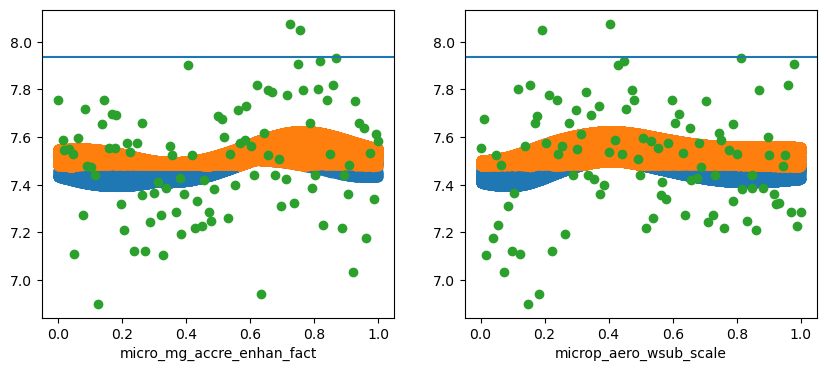

In [77]:
test_case.visualize_check('TMQ_zonal_65to75')

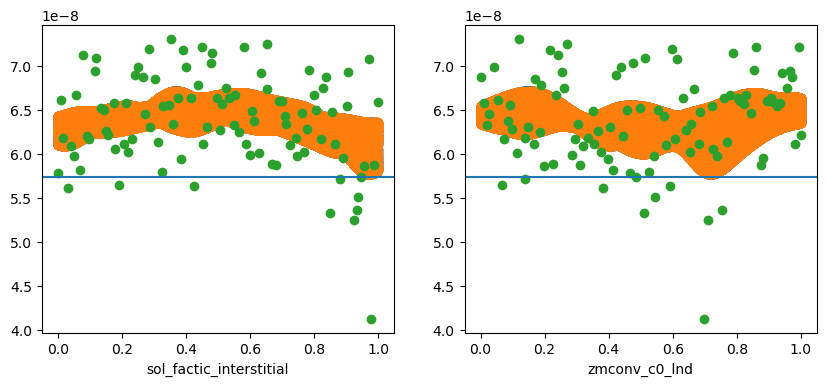

In [71]:
test_case.visualize_check('PRECT_zonal_-5to5')

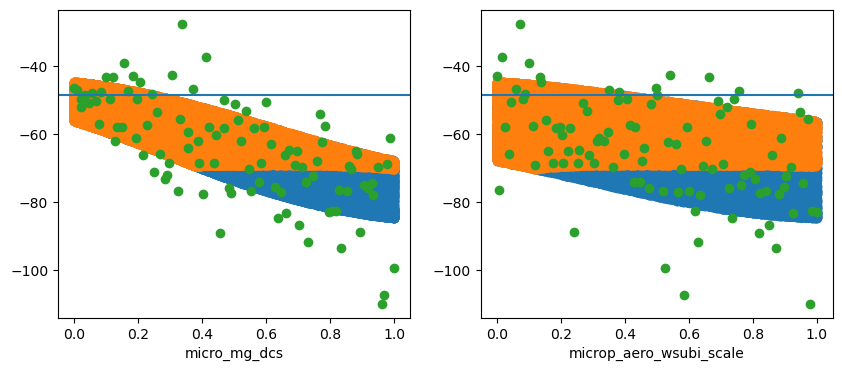

In [34]:
test_case.visualize_check('SWCF_zonal_-5to5')

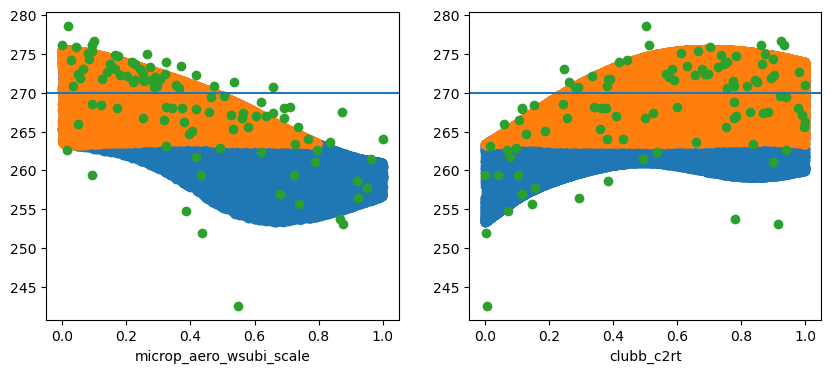

In [99]:
test_case.visualize_check('FLUT_zonal_15to25')

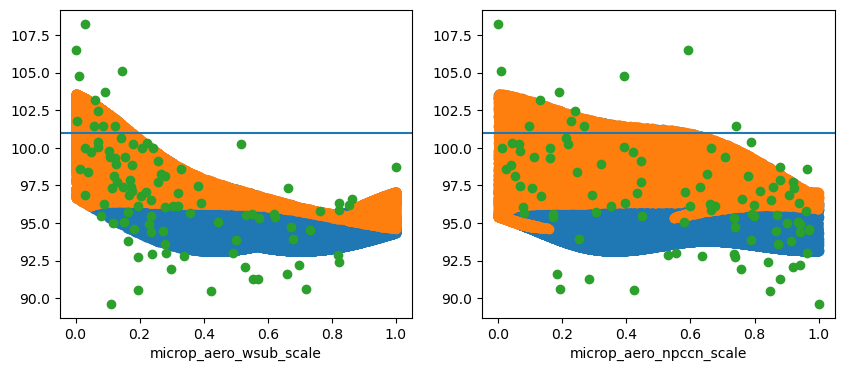

In [101]:
test_case.visualize_check('FSNTOA_zonal_65to75')

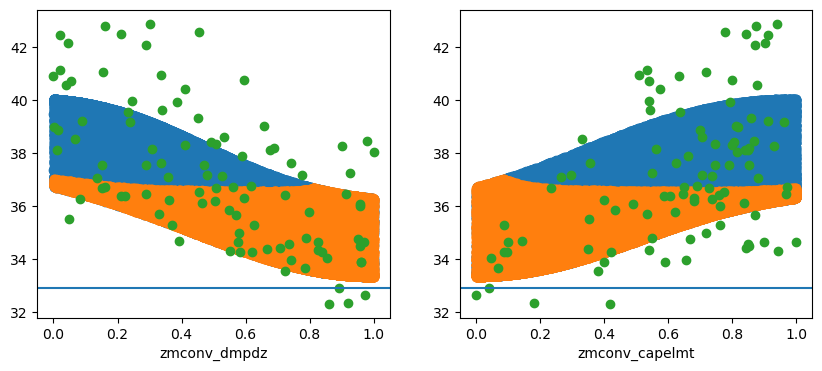

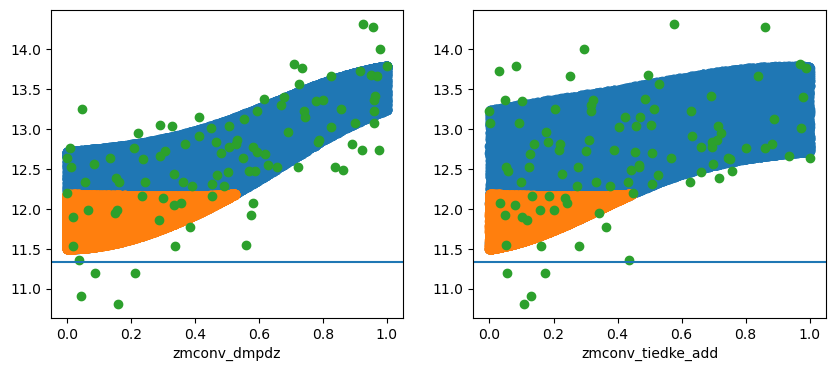

In [63]:
test_case.visualize_check('precip095')

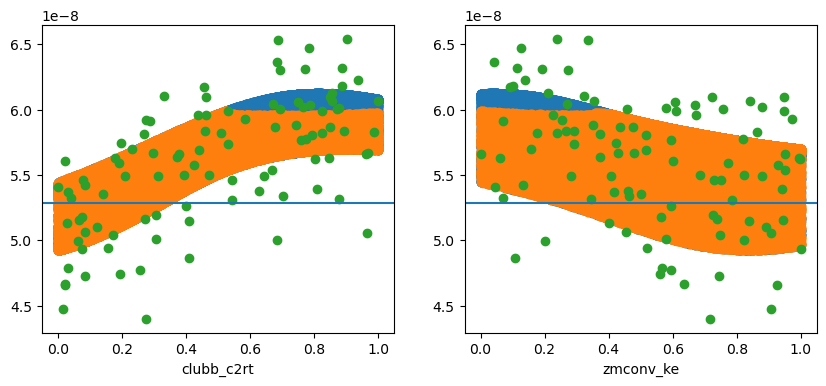

In [65]:
test_case.visualize_check('PRECT_-2_2_1_359')

In [96]:
para_norm = test_case.data_gcm.para_norm
ys = test_case.data_gcm.ppe_pd
obs = test_case.data_gcm.obs_pd


In [102]:
mask = para_norm.microp_aero_wsubi_scale>0.5

In [103]:
para_norm_m = para_norm[mask]
ys_m = ys[mask]


In [104]:
para_norm_m.corrwith(ys_m['PRECT_-2_2_1_359']).abs().sort_values(ascending=False).head(5)

clubb_c2rt                0.516652
micro_mg_vtrmi_factor     0.373488
zmconv_capelmt            0.367096
zmconv_dmpdz              0.360405
sol_factb_interstitial    0.322410
dtype: float64

In [105]:
obs['PRECT_-2_2_1_359']

array(5.28778056e-08)

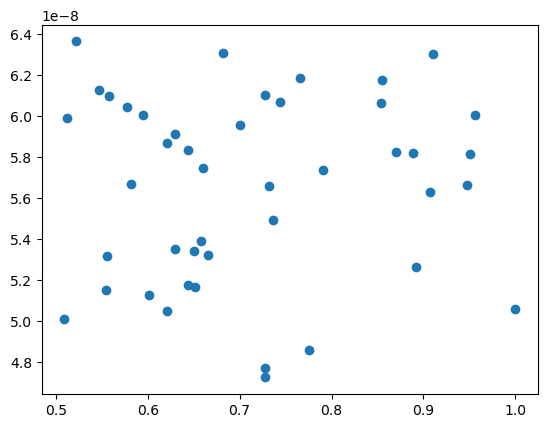

In [106]:
plt.scatter(para_norm_m.microp_aero_wsubi_scale, ys_m['PRECT_-2_2_1_359'])

In [93]:
para_norm_m.corrwith(ys_m['precip099']).abs().sort_values(ascending=False).head(5)

zmconv_dmpdz             0.633827
micro_mg_vtrmi_factor    0.617442
zmconv_capelmt           0.563775
zmconv_num_cin           0.384966
micro_mg_dcs             0.382016
dtype: float64

In [75]:
para_norm_m.corrwith(ys_m['precip095']).abs().sort_values(ascending=False).head(5)

zmconv_dmpdz           0.740440
zmconv_ke              0.381842
zmconv_tiedke_add      0.368769
micro_mg_homog_size    0.347220
zmconv_capelmt         0.334873
dtype: float64